앞선 예제에서 학습한 49개의 데이터로 평가를 한다면 당연히 100% 정답을 맞춥니다.
- kn.score(fish_data, fish_target)
이것은 올바른 평가 방법이 아닙니다.

fit()으로 학습한 것 말고 predict()에는 별도의 데이터를 준비해서 얼마나 잘 훈련되었는지 확인해야 합니다.
### 훈련 세트와 테스트 세트
1. 훈련 세트: 룬련에 사용되는 데이터
2. 테스트 세트: 평가에 사용되는 데이터
---

In [1]:
fish_length = [25.4, 26.3, 26.5, 29.0, 29.0, 29.7, 29.7, 30.0, 30.0, 30.7, 31.0, 31.0,
                31.5, 32.0, 32.0, 32.0, 33.0, 33.0, 33.5, 33.5, 34.0, 34.0, 34.5, 35.0,
                35.0, 35.0, 35.0, 36.0, 36.0, 37.0, 38.5, 38.5, 39.5, 41.0, 41.0, 9.8,
                10.5, 10.6, 11.0, 11.2, 11.3, 11.8, 11.8, 12.0, 12.2, 12.4, 13.0, 14.3, 15.0]
fish_weight = [242.0, 290.0, 340.0, 363.0, 430.0, 450.0, 500.0, 390.0, 450.0, 500.0, 475.0, 500.0,
                500.0, 340.0, 600.0, 600.0, 700.0, 700.0, 610.0, 650.0, 575.0, 685.0, 620.0, 680.0,
                700.0, 725.0, 720.0, 714.0, 850.0, 1000.0, 920.0, 955.0, 925.0, 975.0, 950.0, 6.7,
                7.5, 7.0, 9.7, 9.8, 8.7, 10.0, 9.9, 9.8, 12.2, 13.4, 12.2, 19.7, 19.9]

In [2]:
fish_data = [[l, w] for l, w in zip(fish_length, fish_weight)]
print(fish_data)

[[25.4, 242.0], [26.3, 290.0], [26.5, 340.0], [29.0, 363.0], [29.0, 430.0], [29.7, 450.0], [29.7, 500.0], [30.0, 390.0], [30.0, 450.0], [30.7, 500.0], [31.0, 475.0], [31.0, 500.0], [31.5, 500.0], [32.0, 340.0], [32.0, 600.0], [32.0, 600.0], [33.0, 700.0], [33.0, 700.0], [33.5, 610.0], [33.5, 650.0], [34.0, 575.0], [34.0, 685.0], [34.5, 620.0], [35.0, 680.0], [35.0, 700.0], [35.0, 725.0], [35.0, 720.0], [36.0, 714.0], [36.0, 850.0], [37.0, 1000.0], [38.5, 920.0], [38.5, 955.0], [39.5, 925.0], [41.0, 975.0], [41.0, 950.0], [9.8, 6.7], [10.5, 7.5], [10.6, 7.0], [11.0, 9.7], [11.2, 9.8], [11.3, 8.7], [11.8, 10.0], [11.8, 9.9], [12.0, 9.8], [12.2, 12.2], [12.4, 13.4], [13.0, 12.2], [14.3, 19.7], [15.0, 19.9]]


In [3]:
fish_target = [1]*35 + [0]*14
print(fish_target)

[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


---
훈련 세트와 테스트 세트로 나눠요

In [5]:
train_input = fish_data[:35]
train_target = fish_target[:35]

test_input = fish_data[35:]
test_target = fish_target[35:]

In [6]:
from sklearn.neighbors import KNeighborsClassifier

kn = KNeighborsClassifier()

In [7]:
import numpy as np

kn.fit(np.array(train_input), train_target)

kn.score(np.array(test_input), test_target)

0.0

### 테스트 세트 평가가 0인 이유
49개의 샘플을 골고루 섞어야 하는데 처음부터 35개는 도미인데 이것으로 훈련 세트로 만들고 나머지 빙어로만 테스트 세트로 만들었기 때문입니다. 즉 훈련세트에는 도미 샘플만 테스트 세트에는 빙어 샘플만 있어 문제가 발생했습니다.

=> **샘플링 편향(sampling bias)**

샘플이 골고루 섞여 있지 않아 한쪽으로 치우친 경우를 의미

---

In [8]:
import numpy as np

In [9]:
input_arr = np.array(fish_data)
target_arr = np.array(fish_target)

In [10]:
print(input_arr)

[[  25.4  242. ]
 [  26.3  290. ]
 [  26.5  340. ]
 [  29.   363. ]
 [  29.   430. ]
 [  29.7  450. ]
 [  29.7  500. ]
 [  30.   390. ]
 [  30.   450. ]
 [  30.7  500. ]
 [  31.   475. ]
 [  31.   500. ]
 [  31.5  500. ]
 [  32.   340. ]
 [  32.   600. ]
 [  32.   600. ]
 [  33.   700. ]
 [  33.   700. ]
 [  33.5  610. ]
 [  33.5  650. ]
 [  34.   575. ]
 [  34.   685. ]
 [  34.5  620. ]
 [  35.   680. ]
 [  35.   700. ]
 [  35.   725. ]
 [  35.   720. ]
 [  36.   714. ]
 [  36.   850. ]
 [  37.  1000. ]
 [  38.5  920. ]
 [  38.5  955. ]
 [  39.5  925. ]
 [  41.   975. ]
 [  41.   950. ]
 [   9.8    6.7]
 [  10.5    7.5]
 [  10.6    7. ]
 [  11.     9.7]
 [  11.2    9.8]
 [  11.3    8.7]
 [  11.8   10. ]
 [  11.8    9.9]
 [  12.     9.8]
 [  12.2   12.2]
 [  12.4   13.4]
 [  13.    12.2]
 [  14.3   19.7]
 [  15.    19.9]]


In [11]:
print(input_arr.shape)

(49, 2)


---
### 넘파이를 이용해 무작위로 훈련 세트와 테스트 세트를 만들어 보겠습니다.
1. 인덱스로 사용할 배열을 만듭니다.

    0부터 48까지 1씩 증가하는 배열을 만듭니다.

2. 1번에서 만든 배열을 무작위로 섞습니다.
3. 2번 실행 후 처음부터 35개의 요소를 훈련 세트로 사용하고 나머지는 테스트 세트로 만듭니다.
---
넘파이로 적용
1. np.arange(49) : 정수 49를 전달받아 0부터 49-1까지 1씩 증가하는 배열을 만듭니다.
2. np.random.shuffle(1번에서 만든 배열)
3. test_input = input_arr[index[35:]]  
   test_target = target_arr[index[35:]]

In [12]:
index = np.arange(49)
np.random.shuffle(index)
print(index)

[42 31  0 14 19 20 17 29 21  4 41  8 25 28 27 48  6 12  9  3 35 11 22  5
 44 13 10 18 26 23 15 38 37 43  1  7 33 39 45 46 32 16 34  2 36 24 30 47
 40]


In [13]:
np.random.seed(42)
index = np.arange(49)
np.random.shuffle(index)

In [14]:
print(index)

[13 45 47 44 17 27 26 25 31 19 12  4 34  8  3  6 40 41 46 15  9 16 24 33
 30  0 43 32  5 29 11 36  1 21  2 37 35 23 39 10 22 18 48 20  7 42 14 28
 38]


---
넘파이 배열에 접근하는 방법

In [15]:
print(input_arr)

[[  25.4  242. ]
 [  26.3  290. ]
 [  26.5  340. ]
 [  29.   363. ]
 [  29.   430. ]
 [  29.7  450. ]
 [  29.7  500. ]
 [  30.   390. ]
 [  30.   450. ]
 [  30.7  500. ]
 [  31.   475. ]
 [  31.   500. ]
 [  31.5  500. ]
 [  32.   340. ]
 [  32.   600. ]
 [  32.   600. ]
 [  33.   700. ]
 [  33.   700. ]
 [  33.5  610. ]
 [  33.5  650. ]
 [  34.   575. ]
 [  34.   685. ]
 [  34.5  620. ]
 [  35.   680. ]
 [  35.   700. ]
 [  35.   725. ]
 [  35.   720. ]
 [  36.   714. ]
 [  36.   850. ]
 [  37.  1000. ]
 [  38.5  920. ]
 [  38.5  955. ]
 [  39.5  925. ]
 [  41.   975. ]
 [  41.   950. ]
 [   9.8    6.7]
 [  10.5    7.5]
 [  10.6    7. ]
 [  11.     9.7]
 [  11.2    9.8]
 [  11.3    8.7]
 [  11.8   10. ]
 [  11.8    9.9]
 [  12.     9.8]
 [  12.2   12.2]
 [  12.4   13.4]
 [  13.    12.2]
 [  14.3   19.7]
 [  15.    19.9]]


In [16]:
print(input_arr[1])

[ 26.3 290. ]


In [17]:
print(input_arr[1, 1])

290.0


---
### input_arr 2차원 배열에서 1행과 3행의 값을 출력하기 위한 코드는?

In [18]:
print(input_arr[[1, 3]])

[[ 26.3 290. ]
 [ 29.  363. ]]


---
훈련 세트와 테스트 세트로 나누기

In [21]:
train_input = input_arr[index[:35]]
train_target = target_arr[index[:35]]

In [22]:
print(input_arr[13], train_input[0])

[ 32. 340.] [ 32. 340.]


In [23]:
test_input = input_arr[index[35:]]
test_target = target_arr[index[35:]]

---
산점도

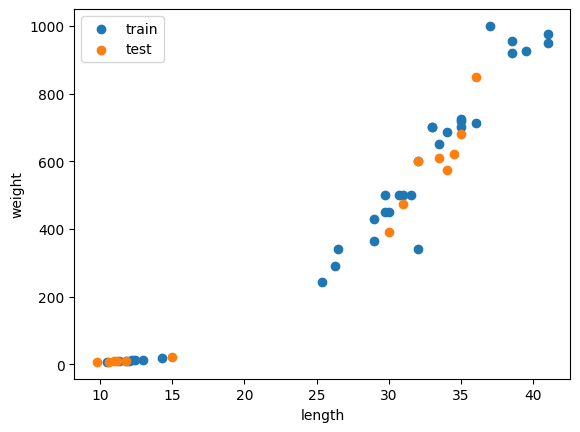

In [36]:
import matplotlib.pyplot as plt

plt.scatter(
    x=train_input[:, 0],
    y=train_input[:, 1],
    label='train'
)
plt.scatter(
    x=test_input[:, 0],
    y=test_input[:, 1],
    label='test'
)
plt.xlabel('length')
plt.ylabel('weight')
plt.legend()
plt.show()

파란색이 훈련 세트이고 주황색이 테스트 세트입니다.

골고루 섞인 것을 확인할 수 있습니다.

---
## 두 번째 머신러닝 프로그램

In [32]:
kn.fit(train_input, train_target)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [33]:
kn.score(test_input, test_target)

1.0

In [34]:
kn.predict(test_input)

array([0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0])

In [35]:
print(test_target)

[0 0 1 0 1 1 1 0 1 1 0 1 1 0]


예측과 실제 타깃 값이 일치합니다.